In [21]:
import uproot
import pandas as pd
import numpy as np
import glob


In [22]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [23]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_Kspip_loose_v7_250122"
cm_elements = ["Kshp_13_had_4S_off_v1", "Kshp_13_had_4S_v3", "Kshp_23_had_4S_off_v1", "Kshp_23_had_4S_v1", "Kshp_23_had_5Sscan_10657_v1", "Kshp_23_had_5Sscan_10706_v1",\
               "Kshp_23_had_5Sscan_10751_v1", "Kshp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [24]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [25]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,36221.000000,36221.000000,36221.000000,36221.000000,36221.000000
mean,1.880876,0.121712,0.403364,1.324541,-0.013721
std,0.110629,0.508637,0.493942,0.756279,0.999920
min,1.600001,-0.984850,-0.907347,0.400010,-1.000000
25%,1.861171,-0.318387,0.009945,0.697982,-1.000000
50%,1.874050,0.165471,0.567857,1.160260,-1.000000
75%,1.968419,0.576564,0.844353,1.774556,1.000000
max,2.099971,0.999993,0.980913,5.221155,1.000000


In [26]:
df_proc13 = df_proc13.query('Dp_M> 1.9 & Dp_M<2.03')


In [27]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,13684.000000,13684.000000,13684.000000,13684.000000,13684.000000
mean,1.969222,0.129946,0.403591,1.438652,-0.012131
std,0.018652,0.501273,0.484722,0.770196,0.999963
min,1.900095,-0.954690,-0.900848,0.400056,-1.000000
25%,1.964986,-0.300913,0.015567,0.823756,-1.000000
50%,1.968971,0.176187,0.562588,1.291184,-1.000000
75%,1.973783,0.578606,0.830143,1.901938,1.000000
max,2.029949,0.999993,0.973172,5.221155,1.000000


In [28]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [58]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250122"
cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [59]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [60]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,154704.000000,154704.000000,154704.000000,154704.000000,154704.000000
mean,1.880716,0.137101,0.431982,1.251266,0.000569
std,0.115700,0.499753,0.489098,0.723271,1.000003
min,1.600001,-0.986512,-0.914323,0.400001,-1.000000
25%,1.855839,-0.285753,0.068869,0.674947,-1.000000
50%,1.875898,0.192979,0.596959,1.061613,1.000000
75%,1.968753,0.573759,0.863339,1.659530,1.000000
max,2.099997,0.998043,0.978815,5.260230,1.000000


In [61]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.9 & Dp_M<2.03')


In [62]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,64343.000000,64343.000000,64343.000000,64343.000000,64343.000000
mean,1.968311,0.120614,0.407285,1.346196,0.004274
std,0.017796,0.493226,0.480679,0.735646,0.999999
min,1.900019,-0.984127,-0.905328,0.400003,-1.000000
25%,1.964930,-0.295242,0.040867,0.765150,-1.000000
50%,1.968619,0.161950,0.556254,1.183815,1.000000
75%,1.972356,0.550998,0.833248,1.769833,1.000000
max,2.029991,0.998043,0.978118,5.105754,1.000000


In [63]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [64]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [65]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


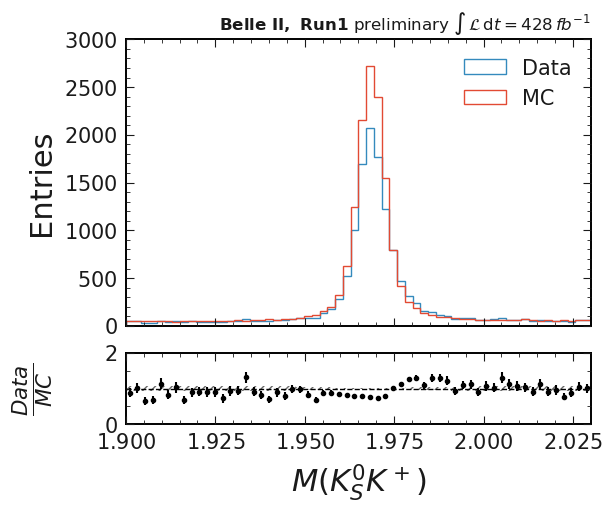

In [67]:
name = "Dp_M"
category = "category"
xlabel = r"$M(K_S^0 K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.9,2.03)

h1 = make_hist(x1, bins=60, range=x_range, weights=1)
h2 = make_hist(x2, bins=60, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}.png", bbox_inches="tight")